# AI Model Experiment & Evaluation

Membandingkan dua pendekatan untuk sentiment analysis ulasan pelanggan:
1. Model klasik Machine Learning (Scikit-learn)
2. LLM API (Gemini)

Dataset: `data/customer_reviews_sentiment.csv` (kolom `review_text` dan `sentiment`).
Sebelum menjalankan notebook, set dulu environment variable `GEMINI_API_KEY`.

## 1. Problem Statement

**Objective**

Tim produk e-commerce ingin membuat fitur yang dapat menentukan secara otomatis apakah sebuah ulasan pelanggan bernada positif atau negatif. Notebook ini membandingkan dua pendekatan, yaitu model klasik yang dilatih dengan Scikit-learn dan LLM (Gemini API) yang hanya menggunakan prompt tanpa training. Hasil perbandingan digunakan untuk menentukan rekomendasi pendekatan yang sebaiknya dikembangkan.

**Target / label**

Yang diprediksi adalah kolom `sentiment` dengan dua kelas:
- `positif`: pelanggan puas, misalnya kualitas barang bagus, pengiriman cepat, atau penjual ramah.
- `negatif`: pelanggan kecewa, misalnya barang rusak atau tidak sesuai, pengiriman lambat, atau penjual tidak responsif.

Fitur yang digunakan hanya `review_text`. Kolom `product_name` tidak digunakan karena sentimen ditentukan dari isi ulasan, bukan dari jenis produknya.

**Batasan dan asumsi**
- Dataset yang digunakan adalah dataset dari brief (200 ulasan berbahasa Indonesia) dan file aslinya tidak diubah.
- Label pada dataset dianggap sudah benar, dan hanya terdapat dua kelas (tidak ada kelas netral).
- Data dibagi 70% train dan 30% test secara stratified dengan `random_state=42`. Test set yang sama digunakan untuk kedua pendekatan.
- LLM digunakan tanpa fine-tuning, hanya dengan zero-shot prompt. API key yang digunakan berada di free tier (maksimal 20 request per hari per model), sehingga ulasan dikirim per batch berisi 10 ulasan dalam satu request.

## 2. Import Library & Load Dataset

In [1]:
import os
import json
import time
import logging

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
from google import genai
from google.genai import types

logging.getLogger('google_genai').setLevel(logging.ERROR)

df = pd.read_csv('../data/customer_reviews_sentiment.csv')
df.head()

,review_id,product_name,review_text,sentiment
0,1,Kemeja Flanel,Pelayanan lambat dan tidak responsif saat diko...,negatif
1,2,Case HP,"Puas banget belanja disini, proses cepat dan b...",positif
2,3,Rice Cooker,"Terima kasih seller, barangnya awet dan sesuai...",positif
3,4,Case HP,Warna produk berbeda jauh dari foto di listing.,negatif
4,5,Headset Bluetooth,"Terima kasih seller, barangnya awet dan sesuai...",positif


In [2]:
print('Ukuran data     :', df.shape)
print('Missing values  :', df.isna().sum().sum())
print('Teks ulasan unik:', df['review_text'].nunique())
print()
print(df['sentiment'].value_counts())

Ukuran data     : (200, 4)
Missing values  : 0
Teks ulasan unik: 40

sentiment
positif    110
negatif     90
Name: count, dtype: int64


Dataset tidak memiliki missing value dan distribusi labelnya cukup seimbang, yaitu 110 positif dan 90 negatif. Namun, dari 200 baris data hanya terdapat 40 kalimat ulasan yang berbeda. Kalimat yang sama muncul berulang kali dengan nama produk yang berbeda. Kondisi ini berpengaruh pada hasil evaluasi dan dibahas lebih lanjut di bagian 7.

## 3. Menyiapkan Train/Test Split

Pada code ini data dibagi menggunakan `train_test_split` dengan parameter `stratify=y` agar proporsi label positif dan negatif di train dan test tetap sama. Test set yang sama digunakan untuk kedua pendekatan agar perbandingannya adil.

In [3]:
X = df['review_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))
print('Label di test set:', y_test.value_counts().to_dict())

Train size: 140
Test size: 60
Label di test set: {'positif': 33, 'negatif': 27}


## 4. Pendekatan 1 - Model Klasik (Scikit-learn)

### 4.1 Preprocessing & Feature Extraction

Pada code ini teks diubah menjadi representasi numerik menggunakan metode TF-IDF (`TfidfVectorizer`). Parameter `ngram_range=(1, 2)` digunakan agar selain kata tunggal (unigram), pasangan kata (bigram) seperti "tidak sesuai" atau "sangat puas" juga terbaca sebagai satu fitur. `TfidfVectorizer` secara default juga mengubah seluruh huruf menjadi lowercase. Vectorizer hanya di-fit pada data train, kemudian digunakan untuk mentransformasi data test.

In [4]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print('Jumlah fitur:', X_train_vec.shape[1])

Jumlah fitur: 384


### 4.2 Training Model

In [5]:
clf = LogisticRegression(max_iter=1000)

start = time.perf_counter()
clf.fit(X_train_vec, y_train)
train_time_classic = time.perf_counter() - start

print(f'Waktu training: {train_time_classic:.4f} detik')

Waktu training: 0.0039 detik


### 4.3 Prediksi pada Test Set

In [6]:
start = time.perf_counter()
y_pred_classic = clf.predict(X_test_vec)
infer_time_classic = time.perf_counter() - start

print(f'Waktu prediksi {len(X_test)} ulasan: {infer_time_classic:.6f} detik')

hasil_classic = pd.DataFrame({'review_text': X_test, 'actual': y_test, 'pred_classic': y_pred_classic})
hasil_classic.head(10)

Waktu prediksi 60 ulasan: 0.000265 detik


,review_text,actual,pred_classic
1,"Puas banget belanja disini, proses cepat dan b...",positif,positif
177,"Kualitas premium dengan harga bersahabat, reco...",positif,positif
188,"Pelayanan ramah dan responsif, barang sampai l...",positif,positif
134,"Puas banget belanja disini, proses cepat dan b...",positif,positif
7,"Belanja disini selalu puas, kualitas terjaga.",positif,positif
135,"Produk original dan berfungsi dengan baik, ter...",positif,positif
125,"Sangat mengecewakan, uang saya seperti terbuan...",negatif,negatif
180,"Mantap, sesuai gambar dan harga terjangkau.",positif,positif
167,"Tidak sesuai standar, banyak cacat pada produk...",negatif,negatif
44,"Barang datang lebih cepat dari perkiraan, kual...",positif,positif


## 5. Pendekatan 2 - LLM API (Gemini)

### 5.1 Setup API

In [7]:
# API key diambil dari environment variable
API_KEY = os.environ.get('GEMINI_API_KEY')
client = genai.Client(api_key=API_KEY) if API_KEY else None
print('Client siap' if client else 'GEMINI_API_KEY belum di-set, hanya bisa pakai hasil yang sudah tersimpan')

Client siap


### 5.2 Merancang Prompt

Prompt pada code ini menggunakan teknik zero-shot, karena klasifikasi sentimen positif/negatif merupakan tugas yang umum bagi LLM sehingga instruksi yang jelas sudah cukup. Dengan zero-shot, prompt menjadi lebih pendek dan tidak ada risiko contoh few-shot yang sama dengan data test.

Isi prompt:
1. Instruksi tugas dengan dua pilihan label yang sama persis dengan label di dataset.
2. Penjelasan singkat kapan ulasan dianggap positif dan kapan negatif. Keluhan soal pengiriman dan pelayanan juga dihitung negatif, bukan hanya keluhan soal produk.
3. Catatan soal negasi, misalnya "tidak mengecewakan" itu positif sedangkan "tidak sesuai" itu negatif.
4. Output diminta dalam bentuk JSON dengan pilihan label yang dibatasi (`positif`/`negatif`) agar jawaban mudah dicocokkan dengan label asli.

Kuota free tier hanya 20 request per hari per model, sedangkan test set berisi 60 ulasan. Oleh karena itu, satu request berisi 10 ulasan yang diberi nomor, dan model mengembalikan label untuk setiap nomor. Total request yang dibutuhkan hanya 6.

Parameter yang digunakan:
- `model = gemini-3.1-flash-lite`: model yang ringan dan murah, cukup untuk klasifikasi dua kelas. Model `gemini-2.0-flash` pada starter notebook sudah tidak tersedia, dan kuota harian `gemini-2.5-flash` sudah habis saat pengujian.
- `temperature = 0`: pada tugas klasifikasi, jawaban harus konsisten dan tidak memerlukan kreativitas. Dengan nilai 0, input yang sama akan menghasilkan label yang sama sehingga hasil eksperimen dapat direproduksi.
- `thinking_level = minimal`: tugas klasifikasi ini sederhana sehingga mode thinking tidak diperlukan. Jika diaktifkan, mode ini hanya menambah waktu respons dan jumlah token.
- `response_schema`: membatasi output ke JSON dengan label `positif` atau `negatif`.
- `BATCH_SIZE = 10`: menyesuaikan dengan batas kuota.

In [8]:
MODEL_NAME = 'gemini-3.1-flash-lite'
BATCH_SIZE = 10

INSTRUKSI = '''Kamu adalah sistem analisis sentimen untuk ulasan pelanggan e-commerce berbahasa Indonesia.
Klasifikasikan sentimen SETIAP ulasan bernomor di bawah sebagai "positif" atau "negatif".
- positif: pelanggan puas atau memuji produk, harga, pengiriman, atau pelayanan penjual.
- negatif: pelanggan kecewa atau mengeluhkan produk (rusak, palsu, tidak sesuai deskripsi/foto/ukuran),
  pengiriman (lambat, packing buruk), atau pelayanan penjual (tidak responsif, komplain diabaikan).
Perhatikan negasi: "tidak mengecewakan" berarti positif, "tidak sesuai" berarti negatif.
Kembalikan label untuk setiap nomor ulasan.'''

OUTPUT_SCHEMA = {
    'type': 'ARRAY',
    'items': {
        'type': 'OBJECT',
        'properties': {
            'id': {'type': 'INTEGER'},
            'sentiment': {'type': 'STRING', 'enum': ['positif', 'negatif']},
        },
        'required': ['id', 'sentiment'],
    },
}

def build_prompt(reviews):
    daftar = '\n'.join(f'{i}. "{text}"' for i, text in enumerate(reviews, 1))
    return f'{INSTRUKSI}\n\nUlasan:\n{daftar}'

def classify_sentiment_llm(reviews):
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=build_prompt(reviews),
        config=types.GenerateContentConfig(
            temperature=0,
            thinking_config=types.ThinkingConfig(thinking_level='minimal'),
            response_mime_type='application/json',
            response_schema=OUTPUT_SCHEMA,
        )
    )
    hasil_json = {item['id']: item['sentiment'] for item in json.loads(response.text)}
    raw = [hasil_json.get(i, '') for i in range(1, len(reviews) + 1)]
    return raw, response.usage_metadata

# contoh prompt untuk 2 ulasan pertama
print(build_prompt(X_test.iloc[:2].tolist()))

Kamu adalah sistem analisis sentimen untuk ulasan pelanggan e-commerce berbahasa Indonesia.
Klasifikasikan sentimen SETIAP ulasan bernomor di bawah sebagai "positif" atau "negatif".
- positif: pelanggan puas atau memuji produk, harga, pengiriman, atau pelayanan penjual.
- negatif: pelanggan kecewa atau mengeluhkan produk (rusak, palsu, tidak sesuai deskripsi/foto/ukuran),
  pengiriman (lambat, packing buruk), atau pelayanan penjual (tidak responsif, komplain diabaikan).
Perhatikan negasi: "tidak mengecewakan" berarti positif, "tidak sesuai" berarti negatif.
Kembalikan label untuk setiap nomor ulasan.

Ulasan:
1. "Puas banget belanja disini, proses cepat dan barang aman."
2. "Kualitas premium dengan harga bersahabat, recommended!"


### 5.3 Menjalankan Prediksi pada Test Set

Output LLM dinormalisasi dulu (lowercase dan strip) sebelum dibandingkan dengan label asli.

Hasil dari API disimpan ke `documentation/llm_predictions.csv`. Ketika notebook dijalankan ulang, hasil tersebut yang digunakan sehingga kuota API tidak terpakai lagi. Untuk memanggil API ulang, ubah `USE_CACHE` menjadi `False`.

In [9]:
def normalize_label(text):
    text = str(text).strip().lower()
    if 'negatif' in text or 'negative' in text:
        return 'negatif'
    if 'positif' in text or 'positive' in text:
        return 'positif'
    return 'unknown'

LLM_CACHE = '../documentation/llm_predictions.csv'
USE_CACHE = True

if USE_CACHE and os.path.exists(LLM_CACHE):
    cache = pd.read_csv(LLM_CACHE, index_col='row_index').loc[X_test.index]
    print('Pakai hasil tersimpan:', LLM_CACHE)
else:
    rows = []
    for b in range(0, len(X_test), BATCH_SIZE):
        batch = X_test.iloc[b:b + BATCH_SIZE]
        for attempt in range(5):
            try:
                start = time.perf_counter()
                raw, usage = classify_sentiment_llm(batch.tolist())
                latency = time.perf_counter() - start
                break
            except Exception as e:
                print('Error, coba lagi:', str(e)[:100])
                time.sleep(20 * (attempt + 1))
        else:
            raise RuntimeError('Request ke Gemini API gagal terus')
        n = len(batch)
        print(f'Batch {b // BATCH_SIZE + 1}: {n} ulasan, {latency:.2f} detik')
        # waktu dan token per request dibagi rata ke tiap ulasan di batch
        for (idx, review), r in zip(batch.items(), raw):
            rows.append({'row_index': idx, 'review_text': review, 'raw_llm': r,
                         'latency_s': latency / n,
                         'input_tokens': usage.prompt_token_count / n,
                         'output_tokens': (usage.candidates_token_count or 0) / n})
        time.sleep(3)
    cache = pd.DataFrame(rows).set_index('row_index')
    cache.to_csv(LLM_CACHE)

raw_outputs = cache['raw_llm'].tolist()
y_pred_llm = [normalize_label(r) for r in raw_outputs]
latencies = cache['latency_s'].tolist()
input_tokens = cache['input_tokens'].tolist()
output_tokens = cache['output_tokens'].tolist()

print('Jumlah prediksi   :', len(y_pred_llm))
print('Output mentah unik:', set(raw_outputs))
print('Output tidak valid:', y_pred_llm.count('unknown'))

Pakai hasil tersimpan: ../documentation/llm_predictions.csv
Jumlah prediksi   : 60
Output mentah unik: {'positif', 'negatif'}
Output tidak valid: 0


In [10]:
hasil = hasil_classic.copy()
hasil['raw_llm'] = raw_outputs
hasil['pred_llm'] = y_pred_llm
hasil['latency_llm_s'] = latencies
hasil.to_csv('../documentation/prediction_results.csv', index_label='row_index')
hasil.head(10)

,review_text,actual,pred_classic,raw_llm,pred_llm,latency_llm_s
1,"Puas banget belanja disini, proses cepat dan b...",positif,positif,positif,positif,0.165717
177,"Kualitas premium dengan harga bersahabat, reco...",positif,positif,positif,positif,0.165717
188,"Pelayanan ramah dan responsif, barang sampai l...",positif,positif,positif,positif,0.165717
134,"Puas banget belanja disini, proses cepat dan b...",positif,positif,positif,positif,0.165717
7,"Belanja disini selalu puas, kualitas terjaga.",positif,positif,positif,positif,0.165717
135,"Produk original dan berfungsi dengan baik, ter...",positif,positif,positif,positif,0.165717
125,"Sangat mengecewakan, uang saya seperti terbuan...",negatif,negatif,negatif,negatif,0.165717
180,"Mantap, sesuai gambar dan harga terjangkau.",positif,positif,positif,positif,0.165717
167,"Tidak sesuai standar, banyak cacat pada produk...",negatif,negatif,negatif,negatif,0.165717
44,"Barang datang lebih cepat dari perkiraan, kual...",positif,positif,positif,positif,0.165717


## 6. Evaluasi dan Perbandingan

Metrik yang digunakan:
- Accuracy: persentase ulasan yang diprediksi dengan benar.
- Precision: dari seluruh ulasan yang diprediksi masuk suatu kelas, berapa persen yang benar termasuk kelas tersebut. Precision positif yang rendah berarti banyak ulasan negatif yang diprediksi positif.
- Recall: dari seluruh ulasan yang sebenarnya termasuk suatu kelas, berapa persen yang berhasil dikenali. Recall negatif yang rendah berarti banyak keluhan yang tidak terdeteksi.
- F1-Score: rata-rata harmonik dari precision dan recall.
- Confusion matrix: baris menunjukkan label asli dan kolom menunjukkan prediksi. Angka pada diagonal adalah prediksi yang benar.

### 6.1 Evaluasi Model Klasik

In [11]:
print('=== Model Klasik (Scikit-learn) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_classic))
print(classification_report(y_test, y_pred_classic, digits=4))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_classic, labels=['negatif', 'positif']))

=== Model Klasik (Scikit-learn) ===
Accuracy: 1.0
              precision    recall  f1-score   support

     negatif     1.0000    1.0000    1.0000        27
     positif     1.0000    1.0000    1.0000        33

    accuracy                         1.0000        60
   macro avg     1.0000    1.0000    1.0000        60
weighted avg     1.0000    1.0000    1.0000        60

Confusion Matrix:
 [[27  0]
 [ 0 33]]


Model klasik memprediksi seluruh ulasan pada test set dengan benar:
- Accuracy 1.00, artinya 60 dari 60 ulasan diprediksi benar.
- Precision 1.00 pada kedua kelas, artinya tidak ada ulasan negatif yang diprediksi positif maupun sebaliknya.
- Recall 1.00 pada kedua kelas, artinya seluruh 27 ulasan negatif dan 33 ulasan positif berhasil dikenali. Tidak ada keluhan yang terlewat.
- F1-Score 1.00, karena precision dan recall sama-sama sempurna.
- Confusion matrix hanya terisi pada diagonal (27 dan 33).

Namun, hasil ini perlu dicermati. Hampir seluruh kalimat pada test set juga terdapat di data train (dicek pada bagian 7), sehingga model lebih banyak "mengingat" kalimat yang sudah pernah dilihat.

### 6.2 Evaluasi LLM API

In [12]:
print('=== LLM API (Gemini) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_llm))
print(classification_report(y_test, y_pred_llm, digits=4, zero_division=0))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_llm, labels=['negatif', 'positif']))

=== LLM API (Gemini) ===
Accuracy: 1.0
              precision    recall  f1-score   support

     negatif     1.0000    1.0000    1.0000        27
     positif     1.0000    1.0000    1.0000        33

    accuracy                         1.0000        60
   macro avg     1.0000    1.0000    1.0000        60
weighted avg     1.0000    1.0000    1.0000        60

Confusion Matrix:
 [[27  0]
 [ 0 33]]


Gemini juga memprediksi seluruh ulasan dengan benar tanpa proses training:
- Accuracy 1.00, artinya 60 dari 60 ulasan diprediksi benar.
- Precision dan recall 1.00 pada kedua kelas, artinya tidak ada kesalahan prediksi dan seluruh keluhan terdeteksi.
- F1-Score 1.00.
- Confusion matrix sama dengan model klasik, hanya terisi pada diagonal.
- Tidak ada output di luar label (`unknown` = 0) karena output sudah dibatasi melalui JSON schema.

Perbedaannya, Gemini tidak pernah melihat data train, sehingga hasil ini berasal dari kemampuan model dalam memahami kalimat, bukan dari hafalan.

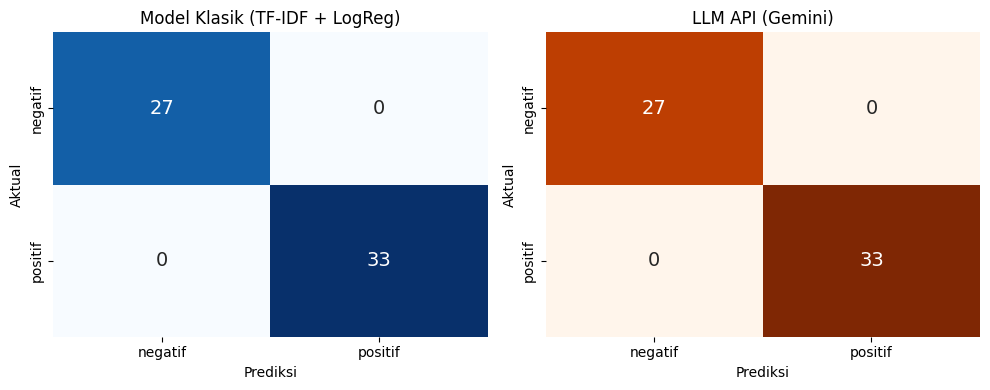

In [13]:
labels = ['negatif', 'positif']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, title, cmap in [(axes[0], y_pred_classic, 'Model Klasik (TF-IDF + LogReg)', 'Blues'),
                              (axes[1], y_pred_llm, 'LLM API (Gemini)', 'Oranges')]:
    sns.heatmap(confusion_matrix(y_test, pred, labels=labels), annot=True, fmt='d', cmap=cmap,
                cbar=False, xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size': 14})
    ax.set_title(title)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.savefig('../documentation/confusion_matrix.png', dpi=150)
plt.show()

### 6.3 Tabel Perbandingan Ringkasan

In [14]:
def ringkas_metrik(y_true, y_pred, nama):
    return {
        'Pendekatan': nama,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

comparison = pd.DataFrame([
    ringkas_metrik(y_test, y_pred_classic, 'Model Klasik (TF-IDF + LogReg)'),
    ringkas_metrik(y_test, y_pred_llm, 'LLM API (Gemini 3.1 Flash-Lite)'),
]).set_index('Pendekatan')

comparison['Waktu training (detik)'] = [train_time_classic, 0]
comparison['Waktu prediksi per ulasan (detik)'] = [infer_time_classic / len(X_test), sum(latencies) / len(latencies)]
comparison.to_csv('../documentation/model_comparison.csv')
comparison.round(6)

,Accuracy,Precision,Recall,F1-Score,Waktu training (detik),Waktu prediksi per ulasan (detik)
Pendekatan,,,,,,
Model Klasik (TF-IDF + LogReg),1.0,1.0,1.0,1.0,0.003851,0.000004
LLM API (Gemini 3.1 Flash-Lite),1.0,1.0,1.0,1.0,0.000000,0.163294


Precision, Recall, dan F1 pada tabel ini menggunakan rata-rata macro (kelas positif dan negatif memiliki bobot yang sama).

Dari sisi metrik, kedua pendekatan menghasilkan nilai yang sama, yaitu 1.00, sehingga test set ini belum dapat menunjukkan pendekatan mana yang lebih baik. Perbedaan baru terlihat pada waktu proses. Model klasik memerlukan training, tetapi hanya membutuhkan sekitar 0.005 detik karena datanya kecil, dan proses prediksinya sangat cepat. Gemini tidak memerlukan training, tetapi membutuhkan sekitar 0.16 detik per ulasan karena request dikirim melalui jaringan. Selisihnya mencapai puluhan ribu kali lebih lambat.

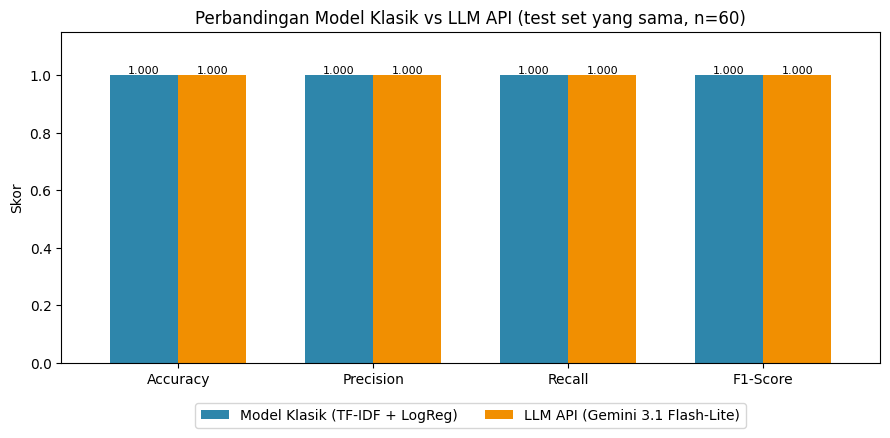

In [15]:
ax = comparison[['Accuracy', 'Precision', 'Recall', 'F1-Score']].T.plot(
    kind='bar', figsize=(9, 4.5), color=['#2E86AB', '#F18F01'], width=0.7)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Skor')
ax.tick_params(axis='x', rotation=0)
ax.set_title('Perbandingan Model Klasik vs LLM API (test set yang sama, n=%d)' % len(y_test))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.savefig('../documentation/model_comparison_summary.png', dpi=150)
plt.show()

## 7. Analisis Trade-off dan Limitation

In [16]:
salah = hasil[(hasil['pred_classic'] != hasil['actual']) | (hasil['pred_llm'] != hasil['actual'])]
print('Ulasan yang salah ditebak:', len(salah))
salah[['review_text', 'actual', 'pred_classic', 'pred_llm']]

Ulasan yang salah ditebak: 0


,review_text,actual,pred_classic,pred_llm


In [17]:
# cek berapa kalimat test yang juga ada di train
overlap = X_test.isin(set(X_train))
print(f'Kalimat test yang juga ada di train: {overlap.sum()} dari {len(X_test)} ({overlap.mean():.0%})')
print('Kalimat test yang tidak ada di train:', X_test[~overlap].tolist())

Kalimat test yang juga ada di train: 59 dari 60 (98%)
Kalimat test yang tidak ada di train: ['Tidak sesuai standar, banyak cacat pada produk yang diterima.']


Karena tidak ada kesalahan prediksi pada test set, code berikut menguji kedua pendekatan dengan 10 ulasan tambahan yang ditulis manual. Gaya bahasanya dibuat mirip ulasan asli di marketplace (mengandung slang, singkatan, sindiran, dan ulasan dengan sentimen campuran), dan labelnya ditentukan secara manual. Pengujian ini hanya untuk melihat potensi kesalahan masing-masing pendekatan, sehingga tidak dimasukkan ke metrik utama. Untuk LLM cukup menggunakan 1 request.

In [18]:
uji_tambahan = pd.DataFrame([
    ('Gak nyesel beli di sini, barangnya ok punya', 'positif'),
    ('Bagus sih kalau tujuannya buat dibuang, baru sehari udah rusak', 'negatif'),
    ('Pengiriman agak lama tapi barangnya bagus banget, worth it', 'positif'),
    ('Barangnya bagus, sayang warnanya salah dan seller gak mau tanggung jawab', 'negatif'),
    ('Tidak ada yang kurang, semuanya perfect', 'positif'),
    ('Wah hebat, pesan seminggu lalu sampai sekarang belum dikirim juga', 'negatif'),
    ('brg sesuai pesanan, pngiriman cpt, mantaap', 'positif'),
    ('Zonk, isinya kosong cuma dus doang', 'negatif'),
    ('Kirain bakal jelek, ternyata malah awet banget', 'positif'),
    ('Seller ramah tapi produknya cacat, jadi percuma', 'negatif'),
], columns=['review_text', 'actual'])

uji_vec = vectorizer.transform(uji_tambahan['review_text'])
uji_tambahan['pred_classic'] = clf.predict(uji_vec)
uji_tambahan['conf_classic'] = clf.predict_proba(uji_vec).max(axis=1).round(2)

UJI_CACHE = '../documentation/llm_predictions_uji_tambahan.csv'
if USE_CACHE and os.path.exists(UJI_CACHE):
    uji_tambahan['pred_llm'] = pd.read_csv(UJI_CACHE)['pred_llm']
else:
    raw_uji, _ = classify_sentiment_llm(uji_tambahan['review_text'].tolist())
    uji_tambahan['pred_llm'] = [normalize_label(r) for r in raw_uji]
    uji_tambahan[['review_text', 'pred_llm']].to_csv(UJI_CACHE, index=False)

for kolom in ['pred_classic', 'pred_llm']:
    print(f'Benar {kolom:12}: {(uji_tambahan[kolom] == uji_tambahan["actual"]).sum()}/{len(uji_tambahan)}')
uji_tambahan

Benar pred_classic: 6/10
Benar pred_llm    : 10/10


,review_text,actual,pred_classic,conf_classic,pred_llm
0,"Gak nyesel beli di sini, barangnya ok punya",positif,positif,0.63,positif
1,"Bagus sih kalau tujuannya buat dibuang, baru s...",negatif,positif,0.51,negatif
2,Pengiriman agak lama tapi barangnya bagus bang...,positif,positif,0.64,positif
3,"Barangnya bagus, sayang warnanya salah dan sel...",negatif,positif,0.70,negatif
4,"Tidak ada yang kurang, semuanya perfect",positif,positif,0.54,positif
5,"Wah hebat, pesan seminggu lalu sampai sekarang...",negatif,negatif,0.55,negatif
6,"brg sesuai pesanan, pngiriman cpt, mantaap",positif,positif,0.51,positif
7,"Zonk, isinya kosong cuma dus doang",negatif,positif,0.53,negatif
8,"Kirain bakal jelek, ternyata malah awet banget",positif,positif,0.57,positif
9,"Seller ramah tapi produknya cacat, jadi percuma",negatif,positif,0.60,negatif


In [19]:
# estimasi biaya Gemini, harga paid tier Gemini 3.1 Flash-Lite:
# input $0.25 / 1 juta token, output $1.50 / 1 juta token (https://ai.google.dev/pricing)
HARGA_INPUT, HARGA_OUTPUT = 0.25, 1.50
biaya = (sum(input_tokens) * HARGA_INPUT + sum(output_tokens) * HARGA_OUTPUT) / 1_000_000

print(f'Rata-rata token input per ulasan : {sum(input_tokens) / len(input_tokens):.1f}')
print(f'Rata-rata token output per ulasan: {sum(output_tokens) / len(output_tokens):.1f}')
print(f'Jumlah request API: {-(-len(X_test) // BATCH_SIZE)} (isi {BATCH_SIZE} ulasan per request)')
print(f'Biaya untuk {len(X_test)} ulasan: ${biaya:.6f}')
print(f'Perkiraan biaya per 1 juta ulasan: ${biaya / len(X_test) * 1_000_000:,.2f}')
print(f'Total waktu LLM   : {sum(latencies):.2f} detik (rata-rata {sum(latencies) / len(latencies):.3f} detik per ulasan)')
print(f'Total waktu klasik: {train_time_classic + infer_time_classic:.4f} detik (training + prediksi)')

Rata-rata token input per ulasan : 32.5
Rata-rata token output per ulasan: 22.1
Jumlah request API: 6 (isi 10 ulasan per request)
Biaya untuk 60 ulasan: $0.002473
Perkiraan biaya per 1 juta ulasan: $41.22
Total waktu LLM   : 9.80 detik (rata-rata 0.163 detik per ulasan)
Total waktu klasik: 0.0041 detik (training + prediksi)


**Performa**

Pada test set utama, kedua pendekatan memperoleh skor 1.00 sehingga tidak ada yang unggul dari sisi metrik. Penyebabnya, dataset hanya memiliki 40 kalimat unik dan 59 dari 60 kalimat pada test set (98%) juga terdapat di data train. Skor sempurna model klasik lebih disebabkan oleh hafalan, belum tentu karena kemampuan generalisasi.

Pada uji tambahan dengan 10 ulasan baru, perbedaan mulai terlihat. Gemini memprediksi benar 10 dari 10 ulasan, sedangkan model klasik hanya 6 dari 10. Keempat kesalahan model klasik merupakan ulasan negatif yang diprediksi positif dengan confidence rendah (0.51 sampai 0.70), yang menunjukkan model sebenarnya hampir menebak secara acak.

**Trade-off**

| Aspek | Model Klasik | LLM API (Gemini) |
|---|---|---|
| Effort | Memerlukan data berlabel, preprocessing, training, dan training ulang jika data berubah | Tidak memerlukan training, cukup merancang prompt dan mengolah output |
| Kebutuhan data | Memerlukan banyak data berlabel yang bervariasi | Tidak memerlukan data train |
| Kecepatan | Sekitar 0.000005 detik per ulasan, berjalan secara lokal | Sekitar 0.16 detik per ulasan (1-2 detik per batch), bergantung pada jaringan |
| Biaya | Hampir tidak ada biaya per prediksi | Sekitar $0.0025 untuk 60 ulasan, atau sekitar $41 per 1 juta ulasan |
| Ketergantungan | Tidak ada | Bergantung pada layanan Google (kuota, rate limit, ketersediaan model) |

**Keterbatasan model klasik**
- Tidak memahami konteks karena hanya melihat bobot kata. Kalimat sindiran seperti "Bagus sih kalau tujuannya buat dibuang..." dan ulasan campuran seperti "Seller ramah tapi produknya cacat" salah diprediksi karena mengandung kata positif seperti "bagus" dan "ramah".
- Kata yang tidak terdapat di data train (misalnya "zonk", slang, atau typo) tidak dikenali, sehingga model cenderung memprediksi kelas mayoritas, yaitu positif. Hal ini berisiko karena keluhan pelanggan dapat lolos sebagai ulasan positif.
- Jumlah data sangat sedikit dan berulang, sehingga skor 1.00 pada test set belum menjamin hasil yang sama baiknya untuk ulasan asli.

**Keterbatasan LLM API**
- Terdapat batas kuota dan rate limit. Pada eksperimen ini, free tier hanya mengizinkan 20 request per hari, sehingga ulasan harus dikirim per batch. Untuk produksi diperlukan paid tier dan mekanisme retry.
- Bergantung pada versi model. Model `gemini-2.0-flash` pada starter notebook sudah tidak dapat digunakan, sehingga code perlu disesuaikan.
- Waktu respons lebih lambat, dan biaya terus bertambah sesuai jumlah ulasan.
- Isi ulasan dikirim ke pihak ketiga, sehingga perlu mempertimbangkan aspek privasi.
- Format jawaban tidak selalu terjamin, sehingga diperlukan JSON schema dan fungsi normalisasi. Pada eksperimen ini tidak ditemukan output yang tidak valid.

## 8. Rekomendasi Technical Approach

Pendekatan yang direkomendasikan adalah **LLM API (Gemini Flash-Lite)** untuk tahap pengembangan berikutnya. Proses klasifikasi dijalankan per batch di background, dan selama berjalan data berlabel dikumpulkan untuk melatih ulang model klasik di kemudian hari.

Alasan:
1. Skor pada test set memang sama, tetapi skor model klasik terbantu karena hampir seluruh kalimat test sudah terdapat di data train. Untuk ulasan dengan gaya bahasa baru, Gemini benar 10/10 sedangkan model klasik 6/10. Seluruh kesalahan model klasik berupa keluhan yang diprediksi positif, dan jenis kesalahan ini paling merugikan bagi tim produk.
2. Effort implementasinya paling kecil karena tidak memerlukan data berlabel dan training. Dengan hanya 40 kalimat unik, dataset saat ini belum cukup untuk melatih model klasik yang andal.
3. Biayanya masih terjangkau, sekitar $41 per 1 juta ulasan dengan Flash-Lite dan batching.
4. Waktu respons sekitar 0.16 detik per ulasan tidak menjadi masalah besar. Label sentimen di halaman produk tidak harus muncul secara real-time, sehingga ulasan dapat diproses di background setelah dikirim oleh pelanggan.

Hal yang perlu disiapkan untuk penerapan di produksi:
- Menggunakan paid tier, disertai mekanisme retry atau antrean agar tidak terkena rate limit.
- Tetap menggunakan output JSON dengan label yang dibatasi dan temperature 0, serta menyimpan hasil prediksi agar ulasan yang sama tidak diproses dua kali.
- Mengunci versi model yang digunakan, dan melakukan evaluasi ulang setiap kali model diganti.
- Memeriksa kualitas secara berkala menggunakan sampel ulasan yang dilabeli manual.

Model klasik tetap lebih sesuai apabila jumlah ulasan sangat besar sehingga biaya API menjadi mahal, apabila dibutuhkan prediksi real-time dalam hitungan milidetik, atau apabila data ulasan tidak boleh dikirim ke pihak ketiga. Hasil prediksi Gemini dapat dimanfaatkan untuk membangun dataset berlabel yang lebih besar, kemudian model klasik dilatih ulang sebagai cadangan ketika API bermasalah atau sebagai alternatif yang lebih murah di kemudian hari.